# SVR for AOR Prediction - Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

In [2]:
# Import the function from the external file
from data.extract_data import extract_sections_by_elements, combine_elements_data

%load_ext autoreload
%autoreload 2

In [3]:
# Call the function to extract sections by element
elements_data = extract_sections_by_elements()

# # Access the data for 'Paracetamol' and 'SingleF'
# paracetamol_singlef_data = elements_data['SingleF']['Paracetamol']
# print(paracetamol_singlef_data)

In [4]:
# Call the function to combine data
combined_data = combine_elements_data(elements_data)

In [5]:
# X=singlef_paracetamol_data[['A:p-p fc', 'B:p-p se', 'C:p-p cr', 'D:p-w fc', 'E:p-w se', 'F:p-w cr', 'G:rr']]
X=combined_data[['A', 'B', 'C', 'D', 'E', 'F', 'G']]
y=combined_data['AOR']

In [6]:
X

,A,B,C,D,E,F,G
0,0.2,0.000050,0.400,0.28,4.000000e-07,0.3,0.600
1,0.3,0.000050,0.400,0.28,4.000000e-07,0.3,0.600
2,0.4,0.000050,0.400,0.28,4.000000e-07,0.3,0.600
3,0.5,0.000050,0.400,0.28,4.000000e-07,0.3,0.600
4,0.6,0.000050,0.400,0.28,4.000000e-07,0.3,0.600
...,...,...,...,...,...,...,...
350,0.2,0.000008,0.200,0.30,5.000000e-08,0.3,0.700
351,0.2,0.000010,0.200,0.30,5.000000e-08,0.3,0.600
352,0.2,0.000010,0.135,0.30,5.000000e-08,0.3,0.669
353,0.2,0.000010,0.113,0.30,5.000000e-08,0.3,0.648


In [7]:
y

0      40.2500
1      42.3050
2      43.6800
3      43.6050
4      43.2150
        ...   
350    34.0975
351    34.2800
352    35.6400
353    35.1900
354    34.5525
Name: AOR, Length: 355, dtype: float64

In [8]:
# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the features
scaler = StandardScaler()

# Fit the scaler only on the training data, then transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Initialize the SVR model with an RBF kernel
svr_model = SVR(kernel='rbf')

# Fit the model to the training data
svr_model.fit(X_train_scaled, y_train)

# Use the trained model to predict the AOR for the test set
y_pred = svr_model.predict(X_test_scaled)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-Squared (R2 Score): {r2}")

Mean Squared Error (MSE): 5.145588313653572
Mean Absolute Error (MAE): 1.5514620371564423
R-Squared (R2 Score): 0.8173403934602618


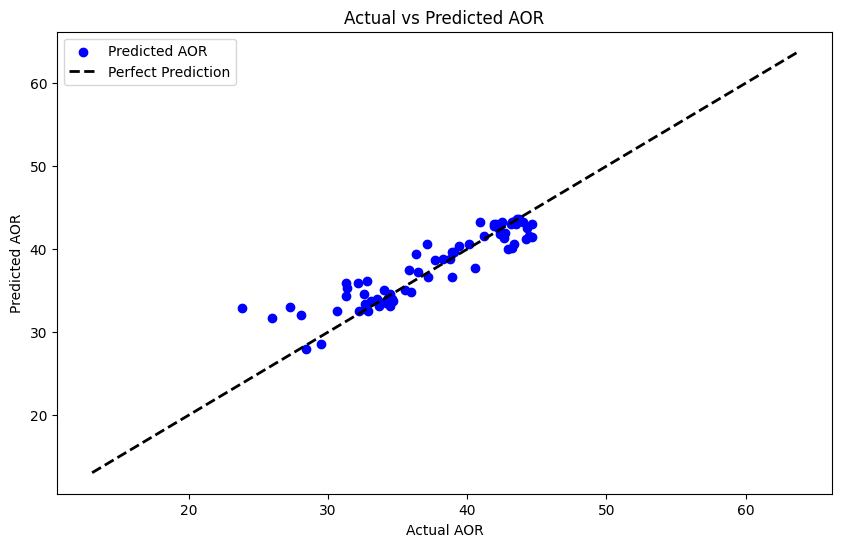

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters from GridSearch: {'C': 26, 'gamma': 'auto', 'kernel': 'rbf'}
Optimized Mean Squared Error (MSE): 2.5701880451050614
Optimized Mean Absolute Error (MAE): 1.1690853877215999
Optimized R-Squared (R2 Score): 0.9087627092501134


In [13]:
# Plot the actual vs predicted values
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted AOR')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual AOR')
plt.ylabel('Predicted AOR')
plt.title('Actual vs Predicted AOR')
plt.legend()
plt.show()

# Define the parameter grid for SVR
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': ['scale', 'auto'],  # Kernel coefficient
    'kernel': ['rbf', 'linear', 'poly']  # Different kernels to test
}

# Initialize GridSearchCV
grid_search = GridSearchCV(SVR(), param_grid, cv=5, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train_scaled, y_train)

# Display the best parameters from GridSearch
print("Best Parameters from GridSearch:", grid_search.best_params_)

# Re-train the model with the best parameters
best_svr_model = grid_search.best_estimator_
best_svr_model.fit(X_train_scaled, y_train)

# Make new predictions with the optimized model
y_pred_best = best_svr_model.predict(X_test_scaled)

# Evaluate the optimized model
mse_best = mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Optimized Mean Squared Error (MSE): {mse_best}")
print(f"Optimized Mean Absolute Error (MAE): {mae_best}")
print(f"Optimized R-Squared (R2 Score): {r2_best}")

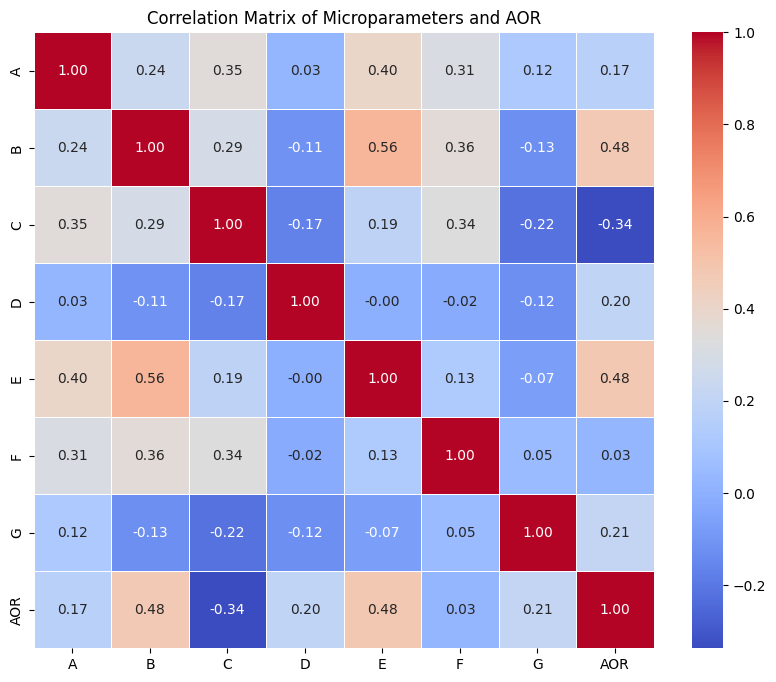

Correlations with AOR:
 AOR    1.000000
E      0.482541
B      0.475126
G      0.212471
D      0.197565
A      0.166894
F      0.025573
C     -0.337008
Name: AOR, dtype: float64


In [11]:
# Compute the correlation matrix
corr_matrix = combined_data.corr()

# Visualize the correlation matrix using Seaborn heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Microparameters and AOR")
plt.show()

# Focus on AOR correlations
print("Correlations with AOR:\n", corr_matrix["AOR"].sort_values(ascending=False))